In [4]:

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from data_models import MixtureClassificationModel, exponential_covariance, TeacherStudentModel, MNISTDataModel, create_downsampling_matrix
from losses_regularizers import LogisticLoss, QuadraticRegularizer,SquaredLoss,PseudoHuberRegularizer, HingeLoss
from erm_theory import ERMTrainer, TheoryFixedPointSolver



c = 5
n = c*6
p = c*10
theta_star = np.zeros(p); theta_star[0] = 1

y_values = [0,1,2]
rng = np.random.default_rng(0)

# W = np.eye(784)[rng.choice(784, size=int(p), replace=False),:]
# W = exponential_covariance(p, rho=0.01)@W
m = 10
W_downsample = create_downsampling_matrix(m)
model = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0.3,
    representation= "random_features",
    classes=[0,1,2,3],
    task="multiclass",
    W=W_downsample,
    activation = 'identity',
    # activation = 'tanh',
)
model_raw = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0.3,
    representation= "raw",
    classes=[0,1],
    task="multiclass",
)


loss = LogisticLoss(max_iter=500, tol=1e-10)
# loss = SquaredLoss()
# loss = HingeLoss()

n_test = 1

model.validate_model_moments()

--- Validating Model: MNISTDataModel ---
Sampling 20000 points...
Class  | Prop (Gamma)    | Mean Diff (Norm)     | Cov Diff (Frobenius)
---------------------------------------------------------------------------
0      | 0.234 vs 0.239 | 0.21791             | 0.61957
1      | 0.271 vs 0.272 | 0.12381             | 0.27045
2      | 0.246 vs 0.241 | 0.23357             | 0.65009
3      | 0.249 vs 0.248 | 0.25675             | 0.56693


Original shape: (784,)
Matrix W shape: (100, 784)


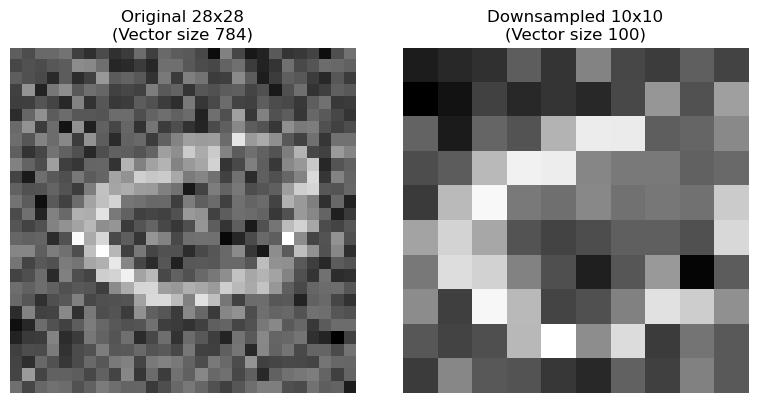

In [7]:
# 1. Load a sample image
x_flat = model_raw.sample_class(0,1)[0].reshape(784,)
img_original = x_flat.reshape(28,28)  # Shape (28, 28)

print(f"Original shape: {x_flat.shape}")
print(f"Matrix W shape: {W_downsample.shape}")

# 3. Apply the transformation: y = W_downsamplex
y_flat = W_downsample @ x_flat
img_small = y_flat.reshape(m, m)

# 4. Visualize
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title(f"Original 28x28\n(Vector size 784)")
plt.imshow(img_original, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Downsampled {m}x{m}\n(Vector size {m*m})")
plt.imshow(img_small, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


In [9]:
mu0 = None
alpha0 = None
nu0 = None
p = model.class_params()['p']
lam = 2
# reg = PseudoHuberRegularizer(lam= lam,  delta = 0.1)

reg = QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
mc_samples = 8000
num_trials =2000
fp_damping =0.1
fp_tol = fp_damping * 2e-4
fp_max_iter = 1000
trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
emp = trainer.run_trials(
    n_train=n,
    num_trials=num_trials,
    rng=rng,
    solver_maxiter=2000,
    tol=1e-6,
    method="L-BFGS-B",
    verbose=False,
)

solver = TheoryFixedPointSolver(
    model=model,
    loss=loss,
    regularizer=reg,
    n_train=n,
    mc_samples=int(mc_samples/np.min([1, lam])),  # more samples for smaller lambda
    rng=np.random.default_rng(123),  # fixed for repeatability
)
th = solver.solve(
        max_iter=fp_max_iter,
        tol=np.max([lam,1]) * fp_tol,
        damping=np.max([lam,1]) * fp_damping,
        verbose=False,
        mu0=mu0,
        alpha0=alpha0,
        nu0=nu0,
    )
print(f"Theory predicted loss: {th['predicted_loss']:.6f}  (converged={th['converged']}, iters={th['num_iter']}, damping_final={th.get('damping_final', float('nan')):.3f})")


Theory predicted loss: 0.343335  (converged=True, iters=337, damping_final=0.011)


In [10]:
num_trials_th = 20000
cl = 1
rng = np.random.default_rng()
Xte, yte = trainer.model.sample_class(cl, num_trials, rng=rng)
rng = np.random.default_rng()
z_samples = rng.standard_normal(size=num_trials_th) 
scores = np.array([Xte[i]@trainer.thetas[i] for i in range(num_trials)])
rng = np.random.default_rng()
Xtetst, ytetst = trainer.model.sample_class(cl,num_trials_th, rng=rng)
scores_th = Xtetst@th["mu_star"]  + th["alpha"][cl]*z_samples


E[emp]≈0.6517, E[the]≈0.6537
std(emp)≈0.1992, std(the)≈0.1897


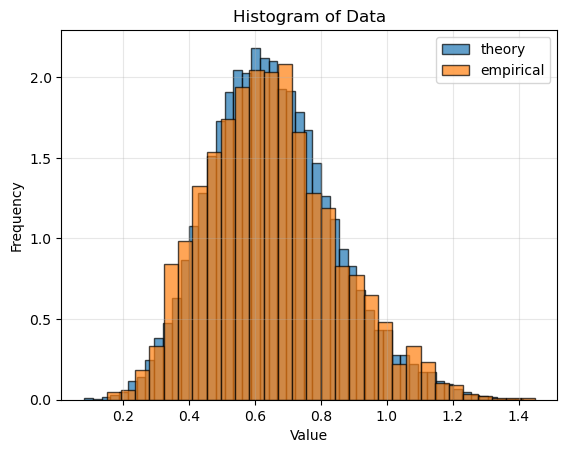

In [11]:
print(f"E[emp]≈{scores[:].mean():.4f}, E[the]≈{scores_th.mean():.4f}")
print(f"std(emp)≈{scores[:].std():.4f}, std(the)≈{scores_th.std():.4f}")
plt.hist(scores_th, density=True, bins=50, edgecolor='black', alpha=0.7, label='theory')
plt.hist(scores, density=True, bins=30, edgecolor='black', alpha=0.7, label='empirical')
# plt.hist(scores_res, density=True, bins=30, edgecolor='black', alpha=0.7, label='resampled')
# plt.hist(Xte[0,:], density=True, bins=20, edgecolor='black', alpha=0.7)
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Data')
plt.grid(alpha=0.3)
plt.show()

E[emp]≈0.6517, E[the]≈0.6537
std(emp)≈0.1992, std(the)≈0.1897


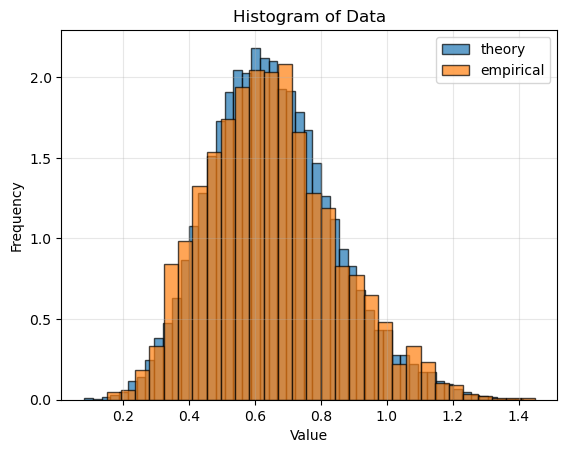

In [12]:
print(f"E[emp]≈{scores[:].mean():.4f}, E[the]≈{scores_th.mean():.4f}")
print(f"std(emp)≈{scores[:].std():.4f}, std(the)≈{scores_th.std():.4f}")
plt.hist(scores_th, density=True, bins=50, edgecolor='black', alpha=0.7, label='theory')
plt.hist(scores, density=True, bins=30, edgecolor='black', alpha=0.7, label='empirical')
# plt.hist(scores_res, density=True, bins=30, edgecolor='black', alpha=0.7, label='resampled')
# plt.hist(Xte[0,:], density=True, bins=20, edgecolor='black', alpha=0.7)
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Data')
plt.grid(alpha=0.3)
plt.show()

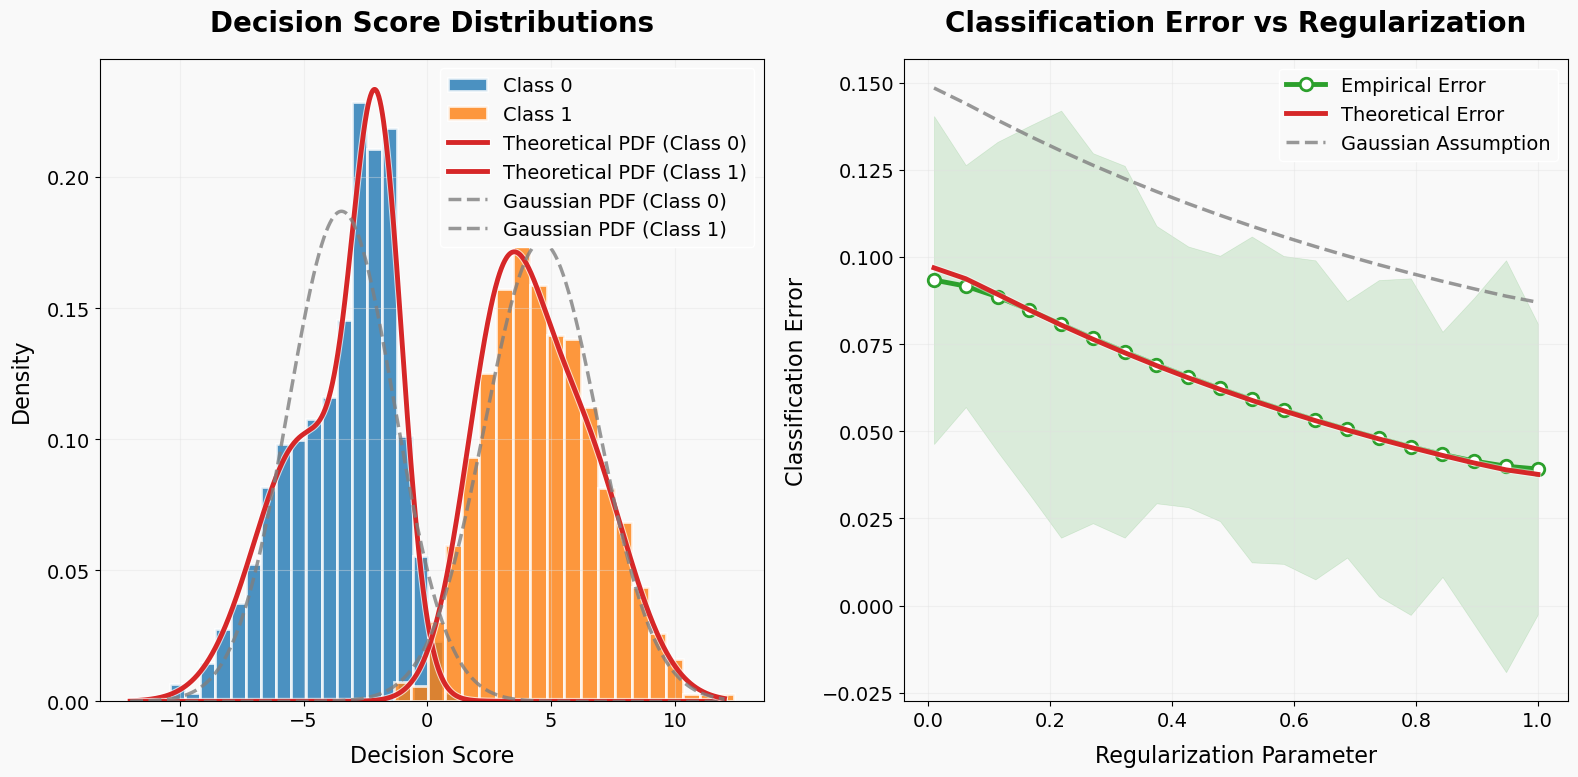

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# =========================
# CONFIGURE FIGURE VISIBILITY AND STYLING
# =========================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 3,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.grid': True,
    'grid.alpha': 0.2,
    'axes.facecolor': '#f9f9f9',
    'figure.facecolor': '#f9f9f9',
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})

# Custom color palette
colors = {
    'class_0': '#1f77b4',
    'class_1': '#ff7f0e',
    'theoretical': '#d62728',
    'gaussian': '#7f7f7f',
    'empirical': '#2ca02c',
    'background': '#f9f9f9',
    'grid': '#e0e0e0',
}

# =========================
# GENERATE SYNTHETIC NON-GAUSSIAN DATA
# =========================
np.random.seed(42)
class_0_scores = np.concatenate([
    np.random.normal(loc=-2, scale=1, size=500),
    np.random.normal(loc=-5, scale=2, size=500)
])
class_1_scores = np.concatenate([
    np.random.normal(loc=3, scale=1.5, size=500),
    np.random.normal(loc=6, scale=2, size=500)
])

# =========================
# THEORETICAL AND GAUSSIAN PDFs
# =========================
def theoretical_pdf_class_0(x):
    return 0.5 * norm.pdf(x, loc=-2, scale=1) + 0.5 * norm.pdf(x, loc=-5, scale=2)
def theoretical_pdf_class_1(x):
    return 0.5 * norm.pdf(x, loc=3, scale=1.5) + 0.5 * norm.pdf(x, loc=6, scale=2)

x_vals = np.linspace(-12, 12, 1000)
y_theoretical_class_0 = theoretical_pdf_class_0(x_vals)
y_theoretical_class_1 = theoretical_pdf_class_1(x_vals)

mean_class_0, std_class_0 = np.mean(class_0_scores), np.std(class_0_scores)
mean_class_1, std_class_1 = np.mean(class_1_scores), np.std(class_1_scores)
y_gaussian_class_0 = norm.pdf(x_vals, loc=mean_class_0, scale=std_class_0)
y_gaussian_class_1 = norm.pdf(x_vals, loc=mean_class_1, scale=std_class_1)

# =========================
# SYNTHETIC CLASSIFICATION ERROR
# =========================
reg_param = np.linspace(0.01, 1, 20)
empirical_error = 0.1 * np.exp(-reg_param)
theoretical_error = 0.1 * np.exp(-reg_param)
gaussian_error = 0.1 * np.exp(-reg_param) + 0.05
empirical_error_std = np.std([empirical_error + 0.05*np.random.randn(20) for _ in range(20)], axis=0)

# Smoothing
empirical_error_smoothed = gaussian_filter1d(empirical_error, sigma=2)
theoretical_error_smoothed = gaussian_filter1d(theoretical_error, sigma=1)
gaussian_error_smoothed = gaussian_filter1d(gaussian_error, sigma=0.5)
empirical_error_std_smoothed = gaussian_filter1d(empirical_error_std, sigma=0.5)

# =========================
# PLOT FIGURE WITH "WOUAH" STYLING
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=colors['background'])

# --- LEFT PANEL: Histograms + PDFs ---
# Histograms with glow effect
axes[0].hist(class_0_scores, bins=20, density=True, alpha=0.8, color=colors['class_0'],
             edgecolor='white', linewidth=2, label='Class 0')
axes[0].hist(class_1_scores, bins=20, density=True, alpha=0.8, color=colors['class_1'],
             edgecolor='white', linewidth=2, label='Class 1')

# Theoretical PDFs (bold, with glow)
axes[0].plot(x_vals, y_theoretical_class_0, color=colors['theoretical'], linewidth=3.5,
             label='Theoretical PDF (Class 0)', path_effects=[path_effects.withStroke(linewidth=5, foreground='white', alpha=0.7)])
axes[0].plot(x_vals, y_theoretical_class_1, color=colors['theoretical'], linewidth=3.5,
             label='Theoretical PDF (Class 1)', path_effects=[path_effects.withStroke(linewidth=5, foreground='white', alpha=0.7)])

# Gaussian PDFs (dashed, subtle)
axes[0].plot(x_vals, y_gaussian_class_0, color=colors['gaussian'], linestyle='--', linewidth=2.5,
             label='Gaussian PDF (Class 0)', alpha=0.8)
axes[0].plot(x_vals, y_gaussian_class_1, color=colors['gaussian'], linestyle='--', linewidth=2.5,
             label='Gaussian PDF (Class 1)', alpha=0.8)

axes[0].set_title("Decision Score Distributions", fontsize=20, pad=20, fontweight='bold')
axes[0].set_xlabel("Decision Score", fontsize=16, labelpad=10)
axes[0].set_ylabel("Density", fontsize=16, labelpad=10)
axes[0].legend(loc='upper right', frameon=True, fontsize=14, framealpha=1, edgecolor='white')
axes[0].grid(True, linestyle='-', color=colors['grid'], alpha=0.4)

# --- RIGHT PANEL: Classification Error ---
# Plot with filled area and shadow
axes[1].plot(reg_param, empirical_error_smoothed, color=colors['empirical'], linewidth=3.5,
             label='Empirical Error', marker='o', markersize=9, markerfacecolor='white',
             markeredgewidth=2, markeredgecolor=colors['empirical'])
axes[1].fill_between(reg_param, empirical_error_smoothed - empirical_error_std_smoothed,
                     empirical_error_smoothed + empirical_error_std_smoothed,
                     color=colors['empirical'], alpha=0.15, edgecolor=colors['empirical'], linewidth=0.5)

axes[1].plot(reg_param, theoretical_error_smoothed, color=colors['theoretical'], linewidth=3.5,
             label='Theoretical Error', path_effects=[path_effects.withStroke(linewidth=5, foreground='white', alpha=0.5)])
axes[1].plot(reg_param, gaussian_error_smoothed, color=colors['gaussian'], linestyle='--', linewidth=2.5,
             label='Gaussian Assumption', alpha=0.8)

axes[1].set_title("Classification Error vs Regularization", fontsize=20, pad=20, fontweight='bold')
axes[1].set_xlabel("Regularization Parameter", fontsize=16, labelpad=10)
axes[1].set_ylabel("Classification Error", fontsize=16, labelpad=10)
axes[1].legend(loc='upper right', frameon=True, fontsize=14, framealpha=1, edgecolor='white')
axes[1].grid(True, linestyle='-', color=colors['grid'], alpha=0.4)

# Tight layout and save
plt.tight_layout()
fig.savefig("ICML_figure.pdf", bbox_inches='tight', dpi=600, facecolor=fig.get_facecolor())
fig.savefig("ICML_figure.png", bbox_inches='tight', dpi=600, facecolor=fig.get_facecolor())
plt.show()


True


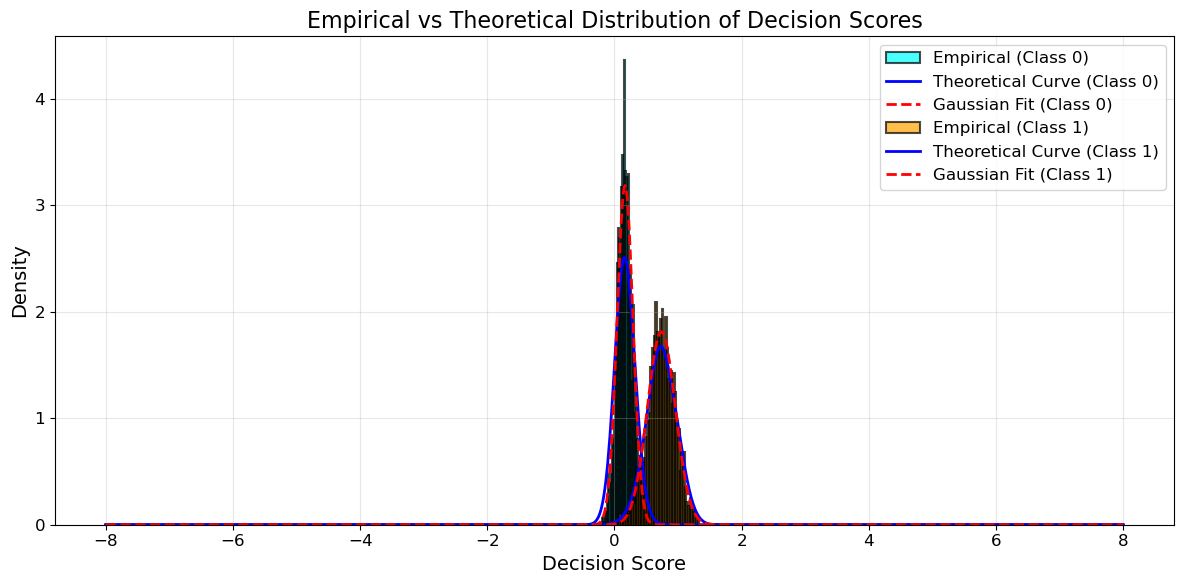

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity  # For Kernel Density Estimation
from data_models import MNISTDataModel, create_downsampling_matrix
from losses_regularizers import LogisticLoss, QuadraticRegularizer, HingeLoss, SquaredLoss
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# =========================
# CONFIGURE FIGURE VISIBILITY
# =========================
plt.rcParams.update({
    'font.size': 12,          # Base font size
    'axes.labelsize': 14,     # x/y labels
    'axes.titlesize': 16,     # subplot titles
    'legend.fontsize': 12,    # legend text
    'lines.linewidth': 2,     # curve thickness
    'xtick.labelsize': 12,    # x-ticks
    'ytick.labelsize': 12     # y-ticks
})

# =========================
# Load MNIST Data and Preprocess
# =========================
m = 20  # Downsampling dimension
W_downsample = create_downsampling_matrix(m)
num_trials = 2000

# Model to use for raw data (binary classification between class 0 and 1)
# model_raw = MNISTDataModel(
#     data_path="mnist.npz",
#     split="test",
#     stats_split="train",
#     noise_std=0.000,
#     representation="raw",
#     classes=[7, 8],  # Binary classification: class 0 and class 1
#     task="multiclass",
# )

# Model to use for feature-based data (random features)
model = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0.000,
    representation="raw",
    classes=[4, 7],  # Binary classification: class 0 and class 1
    task="multiclass",
    W=W_downsample,
    activation="identity",  # Identity function for linear transformation
)

# data_path = 'path_to_your_data.csv'  # Provide the path to your dataset
# model = BinaryClassificationDataModel(data_path=data_path, representation="random_features", noise_std=0.01)


# =========================
# Loss and Regularizer
# =========================
# loss = LogisticLoss(max_iter=500, tol=1e-10)
# loss = HingeLoss()
loss = SquaredLoss()

# =========================
# Train the Empirical Model (ERM)
# =========================
n = 10 * 20  # Example size for training
raw = True
if raw:
    dimension = 784
else:
    dimension = m * m
reg = QuadraticRegularizer(a=np.zeros(dimension), H=2 * np.eye(dimension))  # Regularizer
# reg = PseudoHuberRegularizer(lam = 2,  delta = 0.5)
trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)

# Run empirical trials
emp = trainer.run_trials(
    n_train=n,
    num_trials=2000,
    rng=np.random.default_rng(),
    solver_maxiter=2000,
    tol=1e-6,
    method="L-BFGS-B",
    verbose=True,
)

# =========================
# Theory-based Model
# =========================
solver = TheoryFixedPointSolver(
    model=model,
    loss=loss,
    regularizer=reg,
    n_train=n,
    mc_samples=8000,
    rng=np.random.default_rng(123),
)

# Solve the theoretical fixed point
th = solver.solve(
    max_iter=1000,
    tol=1e-4,
    damping=0.1,
    verbose=False,
)

# =========================
# Collect Empirical and Theoretical Scores for both classes
# =========================
num_trials_th = 20000
cl = [0, 1]  # Loop over class 0 and class 1
scores = {}
scores_th = {}

# Collect empirical and theoretical decision scores for both classes
for c in cl:
    rng = np.random.default_rng()
    Xte, yte = trainer.model.sample_class(c, num_trials, rng=rng)
    scores[c] = np.array([Xte[i] @ trainer.thetas[i] for i in range(num_trials)])

    # Collect theoretical decision scores
    z_samples = rng.standard_normal(size=num_trials_th)
    Xtetst, ytetst = trainer.model.sample_class(c, num_trials_th, rng=rng)
    scores_th[c] = Xtetst @ th["mu_star"] + th["alpha"][c] * z_samples

print(th['converged'])
# =========================
# Plotting the Histogram and Curves
# =========================
plt.figure(figsize=(12, 6))

# Define x-values for plotting the Gaussian fits
x_vals = np.linspace(-8, 8, 1000)

# Plot empirical histograms and theoretical Gaussian fits
for c in cl:
    # Empirical data histogram (class 0 and 1)
    plt.hist(scores[c], bins=50, density=True, alpha=0.7, color='cyan' if c == 0 else 'orange', 
             edgecolor='black', label=f'Empirical (Class {c})', linewidth=1.5)

    # Theoretical data (using Kernel Density Estimation for smooth curve)
    kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(scores_th[c].reshape(-1, 1))  # KDE smooth curve
    log_dens = kde.score_samples(x_vals.reshape(-1, 1))
    plt.plot(x_vals, np.exp(log_dens), color='blue', linewidth=2, label=f'Theoretical Curve (Class {c})')

    # Plot Gaussian PDFs for comparison (red)
    mean_class = np.mean(scores_th[c])
    std_class = np.std(scores_th[c])
    plt.plot(x_vals, norm.pdf(x_vals, loc=mean_class, scale=std_class), 
             color='red', linewidth=2, linestyle='--', label=f'Gaussian Fit (Class {c})')

# Add title, labels, and legend
plt.title("Empirical vs Theoretical Distribution of Decision Scores")
plt.xlabel('Decision Score')
plt.ylabel('Density')
plt.legend(loc='upper right')

# Adjust X-axis for better visibility
# plt.xlim(0, 3)

# Display the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


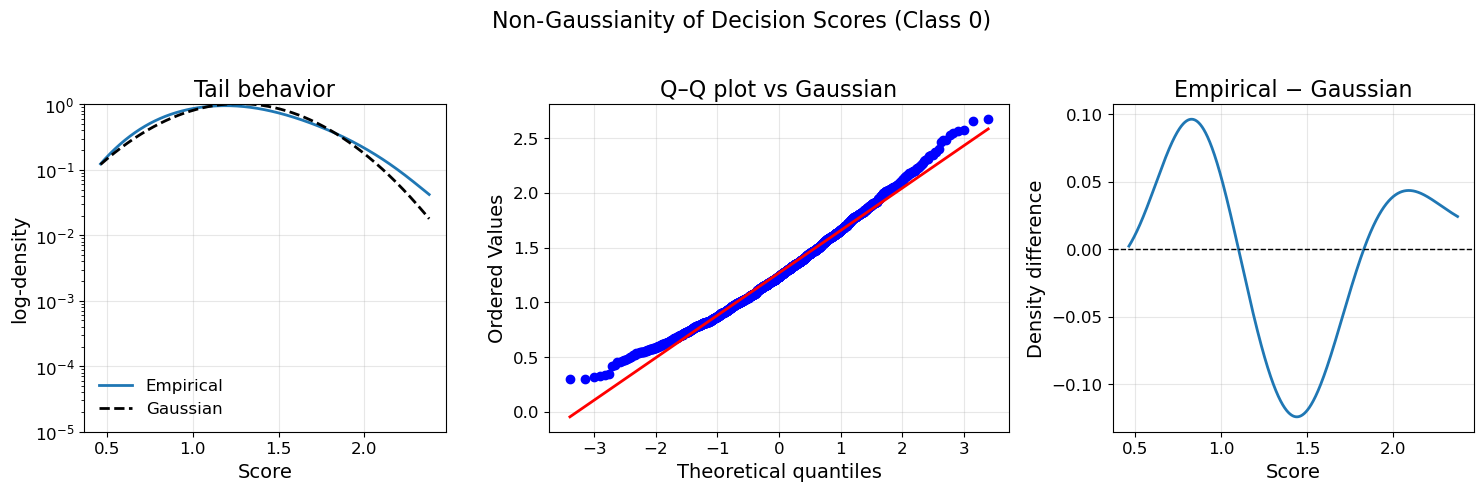

In [26]:
import scipy.stats as stats

# =========================
# SELECT CLASS TO DISPLAY
# =========================
c = 0   # choose class 0 or 1

data = scores[c]
mean = np.mean(data)
std  = np.std(data)

# Common x-axis
x_vals = np.linspace(
    np.percentile(data, 0.5),
    np.percentile(data, 99.5),
    1200
)

# KDE for empirical PDF
kde = KernelDensity(kernel="gaussian", bandwidth=0.15)
kde.fit(data.reshape(-1, 1))
emp_pdf = np.exp(kde.score_samples(x_vals.reshape(-1, 1)))

# Gaussian PDF
gauss_pdf = norm.pdf(x_vals, mean, std)

# =========================
# CREATE 3-PANEL FIGURE
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4.8),
    gridspec_kw={"width_ratios": [1.1, 1.4, 1.1]}
)

# =========================================================
# Panel A — Log-density tails
# =========================================================
ax = axes[0]
ax.plot(x_vals, emp_pdf, label="Empirical", color="tab:blue")
ax.plot(x_vals, gauss_pdf, "--", label="Gaussian", color="black")
ax.set_yscale("log")
ax.set_ylim(1e-5, 1)
ax.set_xlabel("Score")
ax.set_ylabel("log-density")
ax.set_title("Tail behavior")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# =========================================================
# Panel B — Q–Q plot (MAIN PANEL)
# =========================================================
ax = axes[1]
stats.probplot(data, dist="norm", plot=ax)
ax.set_title("Q–Q plot vs Gaussian")
ax.grid(True, alpha=0.3)

# =========================================================
# Panel C — PDF residual
# =========================================================
ax = axes[2]
ax.plot(x_vals, emp_pdf - gauss_pdf, color="tab:blue")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Score")
ax.set_ylabel("Density difference")
ax.set_title("Empirical − Gaussian")
ax.grid(True, alpha=0.3)

# =========================
# FINAL LAYOUT
# =========================
fig.suptitle(
    f"Non-Gaussianity of Decision Scores (Class {c})",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


array([0, 1], dtype=int64)

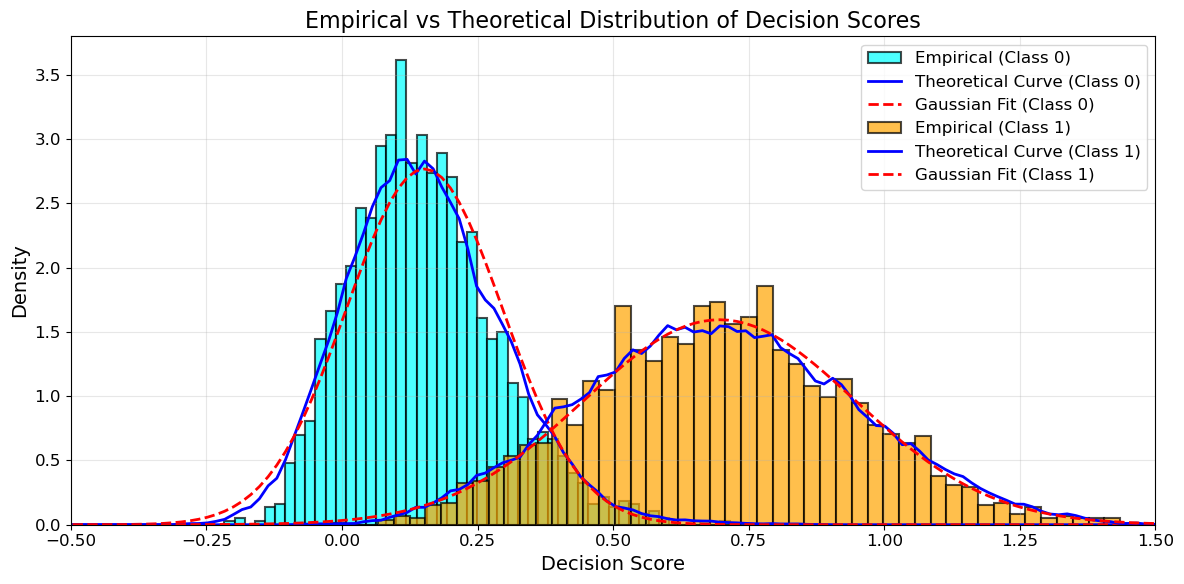

In [3]:
# =========================
# Plotting the Histogram and Curves
# =========================
plt.figure(figsize=(12, 6))

# Define x-values for plotting the Gaussian fits
x_vals = np.linspace(-8, 8, 1000)

# Plot empirical histograms and theoretical Gaussian fits
for c in cl:
    # Empirical data histogram (class 0 and 1)
    plt.hist(scores[c], bins=50, density=True, alpha=0.7, color='cyan' if c == 0 else 'orange', 
             edgecolor='black', label=f'Empirical (Class {c})', linewidth=1.5)

    # Theoretical data (using Kernel Density Estimation for smooth curve)
    kde = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(scores_th[c].reshape(-1, 1))  # KDE smooth curve
    log_dens = kde.score_samples(x_vals.reshape(-1, 1))
    plt.plot(x_vals, np.exp(log_dens), color='blue', linewidth=2, label=f'Theoretical Curve (Class {c})')

    # Plot Gaussian PDFs for comparison (red)
    mean_class = np.mean(scores_th[c])
    std_class = np.std(scores_th[c])
    plt.plot(x_vals, norm.pdf(x_vals, loc=mean_class, scale=std_class), 
             color='red', linewidth=2, linestyle='--', label=f'Gaussian Fit (Class {c})')

# Add title, labels, and legend
plt.title("Empirical vs Theoretical Distribution of Decision Scores")
plt.xlabel('Decision Score')
plt.ylabel('Density')
plt.legend(loc='upper right')

# Adjust X-axis for better visibility
plt.xlim(-0.5, 1.5)

# Display the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

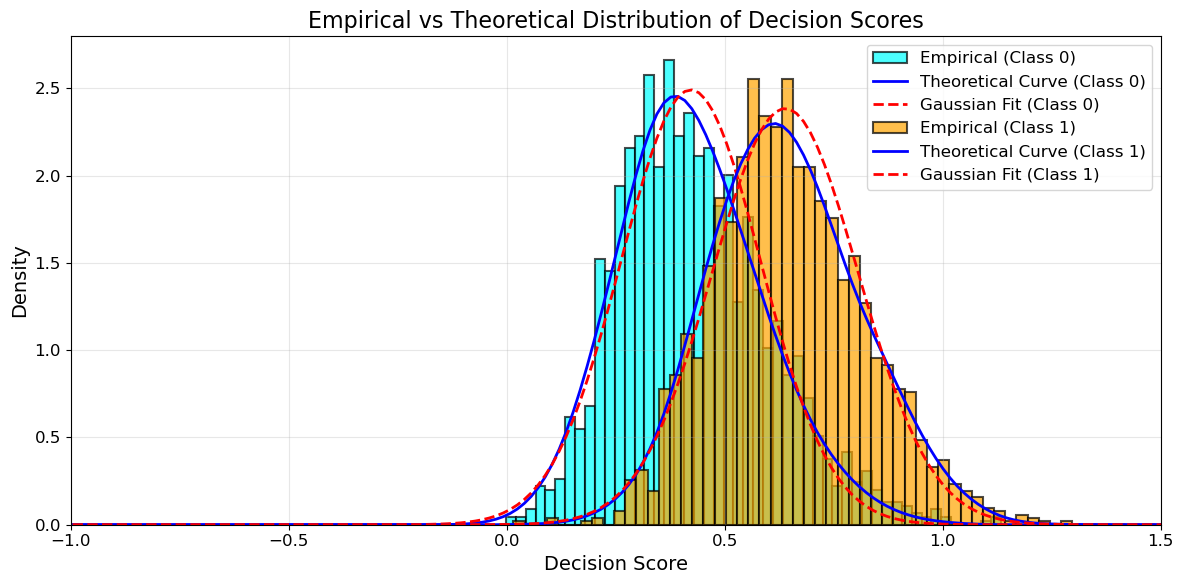

In [39]:
# =========================
# Plotting the Histogram and Curves
# =========================
plt.figure(figsize=(12, 6))

# Define x-values for plotting the Gaussian fits
x_vals = np.linspace(-8, 8, 1000)

# Plot empirical histograms and theoretical Gaussian fits
for c in cl:
    # Empirical data histogram (class 0 and 1)
    plt.hist(scores[c], bins=50, density=True, alpha=0.7, color='cyan' if c == 0 else 'orange', 
             edgecolor='black', label=f'Empirical (Class {c})', linewidth=1.5)

    # Theoretical data (using Kernel Density Estimation for smooth curve)
    kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(scores_th[c].reshape(-1, 1))  # KDE smooth curve
    log_dens = kde.score_samples(x_vals.reshape(-1, 1))
    plt.plot(x_vals, np.exp(log_dens), color='blue', linewidth=2, label=f'Theoretical Curve (Class {c})')

    # Plot Gaussian PDFs for comparison (red)
    mean_class = np.mean(scores_th[c])
    std_class = np.std(scores_th[c])
    plt.plot(x_vals, norm.pdf(x_vals, loc=mean_class, scale=std_class), 
             color='red', linewidth=2, linestyle='--', label=f'Gaussian Fit (Class {c})')

# Add title, labels, and legend
plt.title("Empirical vs Theoretical Distribution of Decision Scores")
plt.xlabel('Decision Score')
plt.ylabel('Density')
plt.legend(loc='upper right')

# Adjust X-axis for better visibility
plt.xlim(-1, 1.5)

# Display the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
import numpy as np
from scipy import stats

# Function to compute the optimal eta based on the means and variances
def compute_optimal_eta(m_1, m_2, sigma_1, sigma_2):
    A = -1/sigma_1 + 1/sigma_2
    B =  2*(-m_2/sigma_2 + m_1/sigma_1)
    C = m_2**2/sigma_2 - m_1**2/sigma_1 + np.log(sigma_2/sigma_1)

    if np.abs(A) < 1e-5:
        eta = -C/B  # Special case: linear equation
    else:
        # Solve the quadratic equation
        intersection_1, intersection_2 = quadratic_formula(A, B, C)
        if (intersection_1 - m_1)*(intersection_1 - m_2) <= 0:
            eta = intersection_1
        else:
            eta = intersection_2

    return eta

# Quadratic formula for solving the quadratic equation
def quadratic_formula(A, B, C):
    discriminant = B**2 - 4 * A * C
    sqrt_discriminant = np.sqrt(discriminant)
    sol1 = (-B + sqrt_discriminant) / (2 * A)
    sol2 = (-B - sqrt_discriminant) / (2 * A)
    return sol1, sol2

In [103]:
def compute_gaussian_error(m_th, variance_th):
    # Unpack the means and variances for both classes
    m_1, m_2 = m_th[0], m_th[1]
    sigma_1, sigma_2 = np.sqrt(variance_th[0]), np.sqrt(variance_th[1])

    # Compute the optimal threshold (eta)
    eta = compute_optimal_eta(m_1, m_2, sigma_1, sigma_2)

    # Sort means and variances to assign the min and max
    m_min, m_max = np.sort(np.array([m_1, m_2]))
    if m_min == m_1:
        var_min = variance_th[0]
        var_max = variance_th[1]
    else:
        var_min = variance_th[1]
        var_max = variance_th[0]

    # Compute probabilities for classification errors based on CDF
    prob_1 = stats.norm.cdf(eta, loc=m_max, scale=np.sqrt(var_max))
    prob_2 = 1 - stats.norm.cdf(eta, loc=m_min, scale=np.sqrt(var_min))

    # Classification error for the Gaussian model
    error_test_th = 0.5 * prob_1 + 0.5 * prob_2
    return error_test_th


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from data_models import MNISTDataModel, create_downsampling_matrix
from losses_regularizers import LogisticLoss, QuadraticRegularizer, HingeLoss, PseudoHuberRegularizer,SquaredLoss,HingeLoss
from erm_theory import ERMTrainer, TheoryFixedPointSolver

# =========================
# CONFIGURE FIGURE VISIBILITY
# =========================
plt.rcParams.update({
    'font.size': 14,          # Base font size
    'axes.labelsize': 16,     # x/y labels
    'axes.titlesize': 18,     # subplot titles
    'legend.fontsize': 14,    # legend text
    'lines.linewidth': 3,     # curve thickness
    'xtick.labelsize': 14,    # x-ticks
    'ytick.labelsize': 14,    # y-ticks
    'axes.grid': True,        # Show grid
    'grid.alpha': 0.3,        # Set grid transparency
})

# =========================
# Load MNIST Data and Preprocess
# =========================
m = 20  # Downsampling dimension
W_downsample = create_downsampling_matrix(m)

# Model to use for raw data (binary classification between class 7 and 8)
model = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    noise_std=0.000,
    representation="raw",
    classes=[7, 8],  # Binary classification: class 0 and class 1
    task="multiclass",
)

# =========================
# Loss and Regularizer
# =========================
loss = LogisticLoss(max_iter=500, tol=1e-10)
# loss =  HingeLoss()

# =========================
# Collect Empirical and Theoretical Scores for both classes
# =========================
num_trials_th = 20000
num_trials = 2000
cl = [0, 1]  # Classes: 7 and 8

# Create storage for errors
empirical_errors = []
empirical_errors_std = []
theoretical_errors = []
theoretical_errors_gaussian = []

# =========================
# Varying Regularization Parameter (lam)
# =========================
lam_values = np.linspace(1, 2, 10)  # Range of regularization parameters
raw = True
if raw:
    dimension = int(np.sqrt(784))
else:
    dimension = m
for lam in lam_values:
    # Regularizer for this specific lambda
#     reg = QuadraticRegularizer(a=np.zeros(dimension * dimension), H=lam * np.eye(dimension * dimension))  # Regularizer
    reg = PseudoHuberRegularizer(lam= lam,  delta = 0.5)

    # Reinitialize and run empirical trials
    trainer = ERMTrainer(model=model, loss=loss, regularizer=reg)
    print('Training')
    emp = trainer.run_trials(
        n_train=10 * 6,
        num_trials=2000,
        rng=np.random.default_rng(),
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )

    # Solve the theoretical model
    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=10 * 6,
        mc_samples=10,
        rng=np.random.default_rng(123),
    )
    print('Theory')
    th = solver.solve(
        max_iter=1000,
        tol=1e-4,
        damping=0.1,
        verbose=False,
    )
    
    # Collect errors for plotting
    empirical_errors.append(emp['gen_loss_mean'])
    empirical_errors_std.append(emp['gen_loss_std'])
    theoretical_errors.append(th['predicted_loss'])
    theoretical_errors_gaussian.append(th['predicted_loss_gauss'])
    print(emp['gen_loss_mean'], emp['gen_loss_std'],  th['predicted_loss'], th['predicted_loss_gauss'])




Training
Theory
0.39276400506684717 0.29566483097440915 0.4076082359106838 0.4049500903077477
Training
Theory
0.4173340595211477 0.29271444658359225 0.4110677535769029 0.4084742495657896
Training
Theory
0.40661259547316136 0.28943148702346516 0.41437347820915527 0.4118508421990158
Training
Theory
0.4102200558320354 0.28695469085803993 0.4175419596769332 0.4150930059185823
Training
Theory
0.41799959561298133 0.2829102928722454 0.4205872958598351 0.41821521767624165
Training
Theory
0.42012462646332716 0.28125452756291824 0.423520748427755 0.4212261501668176
Training
Theory
0.43021381224879685 0.27786806997866154 0.4263522186244859 0.42413655401418404
Training
Theory
0.4397438319543325 0.27351658187569755 0.42908995308127174 0.4269540630139932
Training
Theory
0.43579808387191205 0.27402465541740245 0.4317409337769024 0.4296821750561796
Training
Theory
0.4222443026876065 0.2694649202746048 0.43431167829495215 0.43233159944602906


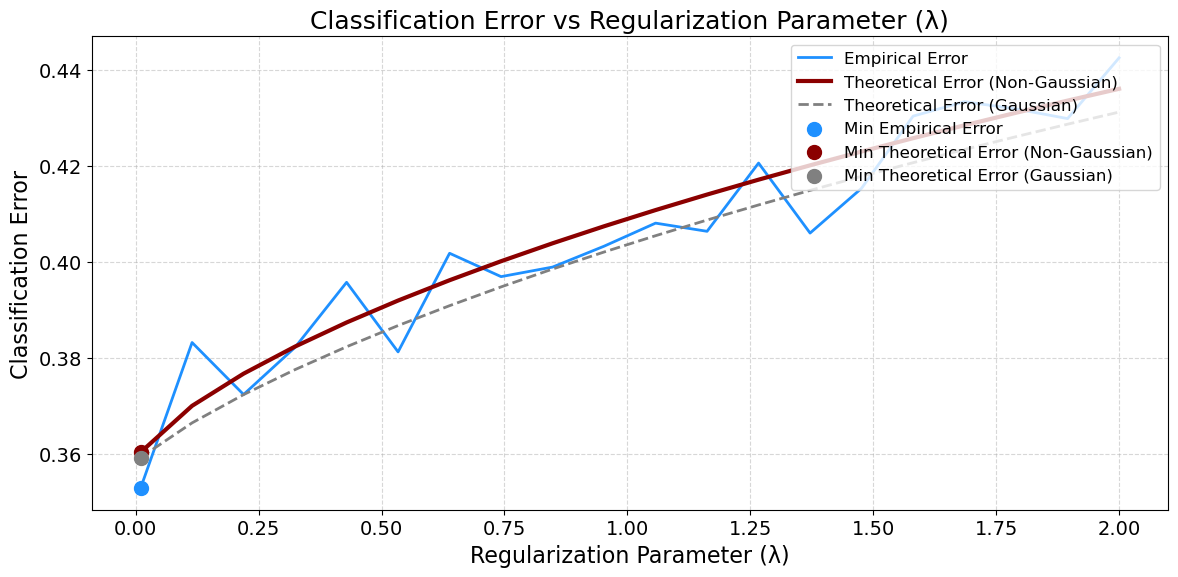

In [8]:
# =========================
# Plotting the Errors as a Function of Regularization (lam)
# =========================
plt.figure(figsize=(12, 6))

# Plot the empirical classification errors with error bars
# plt.errorbar(lam_values, empirical_errors, yerr=empirical_errors_std, label='Empirical Error',
#              fmt='-o', color='dodgerblue', markersize=6, linewidth=2, capsize=4)
plt.plot(lam_values, empirical_errors, label='Empirical Error', color='dodgerblue', markersize=6, linewidth=2)

# Plot the theoretical errors (non-Gaussian and Gaussian)
plt.plot(lam_values, theoretical_errors, label='Theoretical Error (Non-Gaussian)', color='darkred', linewidth=3)
plt.plot(lam_values, theoretical_errors_gaussian, label='Theoretical Error (Gaussian)', color='gray', linestyle='--', linewidth=2)

# Highlight the minimum theoretical and empirical errors for clarity
min_empirical_error = np.min(empirical_errors)
min_theoretical_error = np.min(theoretical_errors)
min_theoretical_gaussian_error = np.min(theoretical_errors_gaussian)

plt.scatter(lam_values[np.argmin(empirical_errors)], min_empirical_error, color='dodgerblue', s=100, zorder=5, label='Min Empirical Error')
plt.scatter(lam_values[np.argmin(theoretical_errors)], min_theoretical_error, color='darkred', s=100, zorder=5, label='Min Theoretical Error (Non-Gaussian)')
plt.scatter(lam_values[np.argmin(theoretical_errors_gaussian)], min_theoretical_gaussian_error, color='gray', s=100, zorder=5, label='Min Theoretical Error (Gaussian)')

# Title and labels
plt.title("Classification Error vs Regularization Parameter (λ)", fontsize=18)
plt.xlabel('Regularization Parameter (λ)', fontsize=16)
plt.ylabel('Classification Error', fontsize=16)

# Legends
plt.legend(loc='upper right', fontsize=12)

# Make the plot visually appealing with grid and layout adjustments
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the plot
plt.show()

λ = 1.00
λ = 2.00


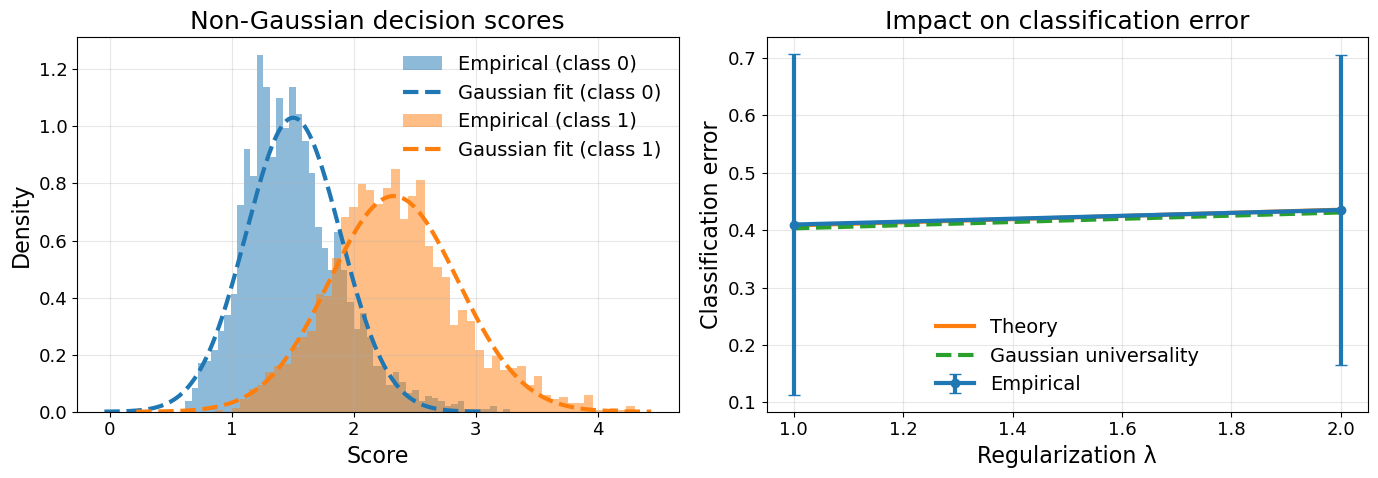

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from data_models import MNISTDataModel
from losses_regularizers import LogisticLoss, PseudoHuberRegularizer
from erm_theory import ERMTrainer, TheoryFixedPointSolver


# ============================================================
# GLOBAL STYLE — publication quality
# ============================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "lines.linewidth": 3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# ============================================================
# DATA MODEL
# ============================================================
model = MNISTDataModel(
    data_path="mnist.npz",
    split="test",
    stats_split="train",
    representation="raw",
    classes=[7, 8],
    task="multiclass",
)

loss = LogisticLoss(max_iter=500, tol=1e-10)


# ============================================================
# EXPERIMENT PARAMETERS
# ============================================================
n_train = 60
num_trials = 2000
num_trials_th = 20000

lam_values = np.linspace(1.0, 2.0, 2)

rng = np.random.default_rng(0)


# ============================================================
# STORAGE
# ============================================================
emp_err, emp_std = [], []
th_err, gauss_err = [], []

scores_emp = {}
scores_th = {}


# ============================================================
# MAIN LOOP OVER λ
# ============================================================
for i, lam in enumerate(lam_values):

    print(f"λ = {lam:.2f}")

    reg = PseudoHuberRegularizer(lam=lam, delta=0.5)
    trainer = ERMTrainer(model, loss, reg)

    emp = trainer.run_trials(
        n_train=n_train,
        num_trials=num_trials,
        rng=rng,
        solver_maxiter=2000,
        tol=1e-6,
        method="L-BFGS-B",
        verbose=False,
    )

    solver = TheoryFixedPointSolver(
        model=model,
        loss=loss,
        regularizer=reg,
        n_train=n_train,
        mc_samples=5000,
        rng=rng,
    )

    th = solver.solve(max_iter=1000, tol=1e-4, damping=0.1)

    # --- store errors
    emp_err.append(emp["gen_loss_mean"])
    emp_std.append(emp["gen_loss_std"])
    th_err.append(th["predicted_loss"])
    gauss_err.append(th["predicted_loss_gauss"])

    # --- store score distributions for FIRST λ only
    if i == 0:
        for c in [0, 1]:
            X, _ = trainer.model.sample_class(c, num_trials, rng=rng)
            scores_emp[c] = np.array([
                X[j] @ trainer.thetas[j] for j in range(num_trials)
            ])

            z = rng.standard_normal(num_trials_th)
            Xth, _ = trainer.model.sample_class(c, num_trials_th, rng=rng)
            scores_th[c] = Xth @ th["mu_star"] + th["alpha"][c] * z


# ============================================================
# FIGURE — 1×2 PANEL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ------------------------------------------------------------
# LEFT PANEL — score distributions
# ------------------------------------------------------------
colors = ["tab:blue", "tab:orange"]

for c in [0, 1]:
    mu = scores_th[c].mean()
    std = scores_th[c].std()

    axes[0].hist(
        scores_emp[c],
        bins=50,
        density=True,
        alpha=0.5,
        color=colors[c],
        label=f"Empirical (class {c})",
    )

    x = np.linspace(mu - 4 * std, mu + 4 * std, 500)
    axes[0].plot(
        x,
        norm.pdf(x, mu, std),
        "--",
        color=colors[c],
        label=f"Gaussian fit (class {c})",
    )

axes[0].set_title("Non-Gaussian decision scores")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False)


# ------------------------------------------------------------
# RIGHT PANEL — classification error
# ------------------------------------------------------------
axes[1].errorbar(
    lam_values,
    emp_err,
    yerr=emp_std,
    fmt="o-",
    capsize=4,
    label="Empirical",
)

axes[1].plot(lam_values, th_err, label="Theory")
axes[1].plot(lam_values, gauss_err, "--", label="Gaussian universality")

axes[1].set_title("Impact on classification error")
axes[1].set_xlabel("Regularization λ")
axes[1].set_ylabel("Classification error")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()
